# Graph Construction Method & Embedding Analyzer

This notebook analyzes how the chosen threshold during the graph construction phase impacts the model's ultimate forecasting performance (`RMSE` and `MAE`). It parses the aggregated results generated by checking varying boundaries on metrics such as `pearson`, `spearman`, and others.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid")

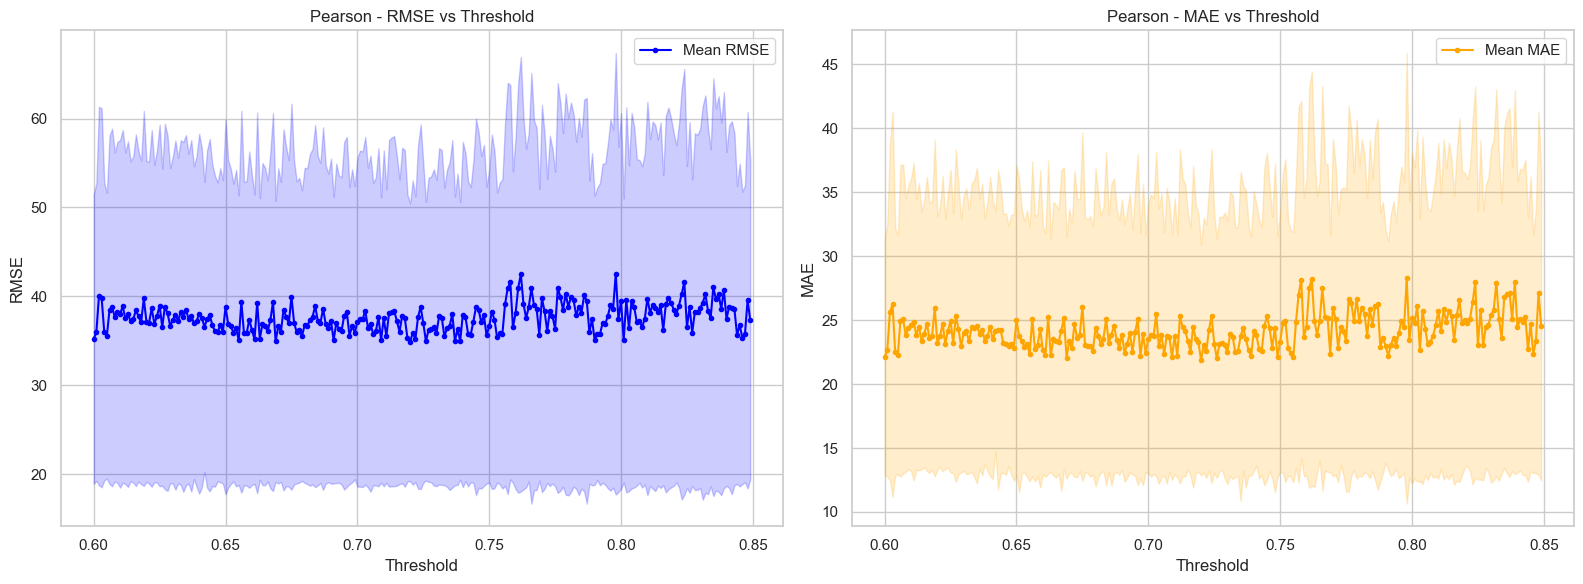

Optimal Threshold for pearson based on Average RMSE: 0.72
Optimal Threshold for pearson based on Average MAE : 0.72


In [2]:
# Define the metric you want to analyze
metric = "pearson" # "spearman", "amplitude_offset"
csv_path = f"{metric}.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    # We are mainly interested in runs evaluating the threshold parameters (excluding purely percentile runs)
    df_thresh = df[df['threshold'].notna()].copy()
    
    if len(df_thresh) > 0:
        # Group by threshold to observe overall convergence / variance
        grouped = df_thresh.groupby('threshold')[['rmse', 'mae']].agg(['mean', 'std'])
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot RMSE 
        axes[0].plot(grouped.index, grouped[('rmse', 'mean')], label='Mean RMSE', color='blue', marker='.')
        axes[0].fill_between(grouped.index, 
                             grouped[('rmse', 'mean')] - grouped[('rmse', 'std')],
                             grouped[('rmse', 'mean')] + grouped[('rmse', 'std')],
                             color='blue', alpha=0.2)
        axes[0].set_title(f'{metric.capitalize()} - RMSE vs Threshold')
        axes[0].set_xlabel('Threshold')
        axes[0].set_ylabel('RMSE')
        axes[0].legend()
        
        # Plot MAE
        axes[1].plot(grouped.index, grouped[('mae', 'mean')], label='Mean MAE', color='orange', marker='.')
        axes[1].fill_between(grouped.index, 
                             grouped[('mae', 'mean')] - grouped[('mae', 'std')],
                             grouped[('mae', 'mean')] + grouped[('mae', 'std')],
                             color='orange', alpha=0.2)
        axes[1].set_title(f'{metric.capitalize()} - MAE vs Threshold')
        axes[1].set_xlabel('Threshold')
        axes[1].set_ylabel('MAE')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Identify the best performing threshold limit
        best_threshold_rmse = df_thresh.groupby('threshold')['rmse'].mean().idxmin()
        best_threshold_mae = df_thresh.groupby('threshold')['mae'].mean().idxmin()
        
        print(f"Optimal Threshold for {metric} based on Average RMSE: {best_threshold_rmse}")
        print(f"Optimal Threshold for {metric} based on Average MAE : {best_threshold_mae}")
    else:
        print(f"No threshold data plotted for {metric} - (check if only percentiles were ran)")
else:
    print(f"CSV file not found: {csv_path}")

## Multi-Metric Cross Comparison
To quickly isolate which connectivity metric naturally holds the best baseline structure before threshold grid search:

,Metric,Best Threshold,Lowest Avg RMSE
1,spearman,0.669,34.430645
0,pearson,0.720,34.831689
2,amplitude_offset,2.633,45.994816


C:\Temp\ipykernel_24296\374473746.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df.sort_values(by="Lowest Avg RMSE"), x="Metric", y="Lowest Avg RMSE", palette="viridis")


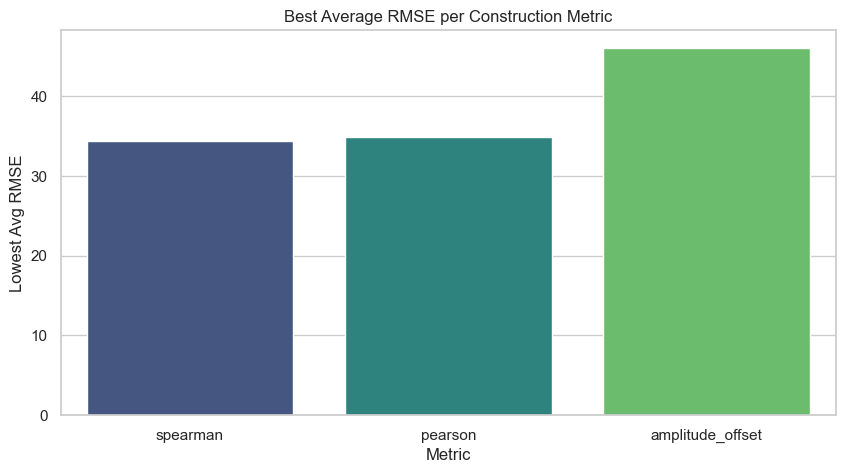

In [3]:
metrics_available = ["pearson", "spearman", "amplitude_offset"]
best_summary = []

for m in metrics_available:
    path = f"{m}.csv"
    if os.path.exists(path):
        m_df = pd.read_csv(path)
        m_thresh = m_df[m_df['threshold'].notna()].copy()
        
        if len(m_thresh) > 0:
            avg_rmse = m_thresh.groupby('threshold')['rmse'].mean()
            best_thresh = avg_rmse.idxmin()
            lowest_rmse = avg_rmse.min()
            best_summary.append({"Metric": m, "Best Threshold": best_thresh, "Lowest Avg RMSE": lowest_rmse})

summary_df = pd.DataFrame(best_summary)
if len(summary_df) > 0:
    display(summary_df.sort_values(by="Lowest Avg RMSE"))
    
    # Plot comparative distributions 
    plt.figure(figsize=(10, 5))
    sns.barplot(data=summary_df.sort_values(by="Lowest Avg RMSE"), x="Metric", y="Lowest Avg RMSE", palette="viridis")
    plt.title("Best Average RMSE per Construction Metric")
    plt.show()